# AD 判定手法の比較: Boston Housing データ

Audience:
- 第7回 Python セミナーで kNN 距離による Applicability Domain (AD) を学んだ人。

Prerequisites:
- Hold-Out 検証、標準化、回帰モデルの評価指標 (MAE/RMSE/R2) の基本。
- kNN 距離による AD 判定の考え方。

Learning goals:
- kNN 距離以外の AD 判定方法を同じデータで試す。
- 手法ごとの AD 内外件数、予測誤差、判定の一致/不一致を比較する。
- AD 外判定を「予測値を疑うための補助情報」として読む。

## Outline

1. データを読み込み、既存ノートブックと同じ Hold-Out 分割を作る。
2. 複数の回帰モデルを比較し、AD 解析に使う予測値を決める。
3. 6種類の AD 判定手法を同じしきい値ルールで実行する。
4. AD 内外の件数・誤差・判定一致度を比較する。
5. PCA 平面上で、手法ごとの AD 外サンプルを可視化する。
6. 演習として、しきい値を変えたときの結果を確認する。

## 1. ライブラリの読み込み

追加の依存は使わず、`lesson_7` の `pyproject.toml` に入っている scikit-learn / pandas / numpy / matplotlib / seaborn だけで進めます。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM, SVR
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 80)

RANDOM_STATE = 42
K_NEIGHBORS = 5
AD_PERCENTILE = 95
CONTAMINATION = 1 - AD_PERCENTILE / 100

## 2. データの読み込みと Hold-Out 分割

既存ノートブックと同じく、`MEDV` を目的変数、それ以外を説明変数として扱います。AD 判定では説明変数空間での「学習データからの離れ方」を見ます。

In [2]:
data_path = Path("boston.csv")
df = pd.read_csv(data_path, index_col=0)

target_col = "MEDV"
X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"データ数: {df.shape[0]}")
print(f"特徴量数: {X.shape[1]}")
print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")
display(df.head())

データ数: 506
特徴量数: 13
学習データ数: 379
テストデータ数: 127


,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


## 3. 標準化と回帰モデルの比較

距離・密度・境界に基づく AD 手法は、特徴量のスケール差の影響を強く受けます。そのため、学習データだけで標準化を `fit` し、テストデータはその基準で `transform` します。

ここでは既存ノートブックと同様に複数モデルを Hold-Out で比較し、RMSE が最小のモデルの予測値を AD 解析に使います。

Hold-Out 検証のモデル比較


,model,MAE,RMSE,R2
0,Gradient Boosting,2.028,2.993,0.872
1,Random Forest,2.176,3.359,0.839
2,Hist Gradient Boosting,2.104,3.376,0.837
3,Extra Trees,2.006,3.447,0.830
4,Decision Tree,2.718,3.709,0.804
5,SVR (RBF),2.130,3.755,0.799
6,AdaBoost,2.690,4.002,0.771
7,kNN,2.557,4.488,0.712
8,Linear Regression,3.061,4.701,0.684
9,Ridge,3.059,4.703,0.684


AD 解析に使うモデル: Gradient Boosting


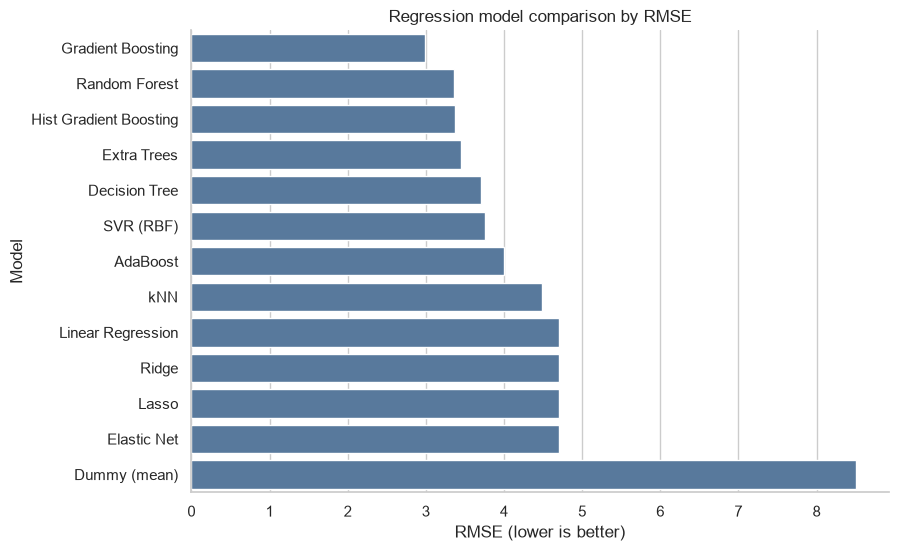

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1),
    "Decision Tree": DecisionTreeRegressor(min_samples_leaf=2, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
}

model_predictions = {}
model_score_rows = []

for model_name, candidate_model in models.items():
    candidate_model.fit(X_train_scaled, y_train)
    candidate_pred = candidate_model.predict(X_test_scaled)
    model_predictions[model_name] = candidate_pred
    model_score_rows.append(
        {
            "model": model_name,
            "MAE": mean_absolute_error(y_test, candidate_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, candidate_pred)),
            "R2": r2_score(y_test, candidate_pred),
        }
    )

model_scores = (
    pd.DataFrame(model_score_rows)
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

selected_model_name = model_scores.loc[0, "model"]
y_pred = model_predictions[selected_model_name]
residual = y_test.to_numpy() - y_pred
abs_error = np.abs(residual)

print("Hold-Out 検証のモデル比較")
display(model_scores.round({"MAE": 3, "RMSE": 3, "R2": 3}))
print(f"AD 解析に使うモデル: {selected_model_name}")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=model_scores, x="RMSE", y="model", color="#4C78A8", ax=ax)
ax.set_title("Regression model comparison by RMSE")
ax.set_xlabel("RMSE (lower is better)")
ax.set_ylabel("Model")
plt.show()

## 4. 比較する AD 判定手法

このノートブックでは、すべての手法を「異常度スコアが大きいほど AD 外に近い」という形にそろえます。しきい値は、各手法で計算した **学習データの異常度スコアの 95 パーセンタイル** とします。

| 手法 | 見ているもの | 向いている状況 | 注意点 |
|---|---|---|---|
| kNN mean distance | 近傍までの平均距離 | 学習データの局所的な疎密を見たい | k と距離尺度に依存する |
| Mahalanobis distance | 共分散を考慮した中心からの距離 | 分布が楕円形に近い | 非線形・多峰性の分布に弱い |
| PCA reconstruction error | 主成分で再構成できない度合い | 低次元構造から外れる点を見たい | 主成分数に依存する |
| One-Class SVM | 非線形な境界の外側 | 境界ベースで AD を作りたい | `nu` や `gamma` に敏感 |
| Isolation Forest | 木で孤立しやすい度合い | 外れ値検出として手早く使いたい | ランダム性と contamination に依存する |
| Local Outlier Factor | 周辺密度と比べた低密度さ | 局所密度の違いを見たい | novelty 判定では学習時と推論時の使い方に注意 |

In [4]:
def rmse_from_residual(values: np.ndarray) -> float:
    if len(values) == 0:
        return np.nan
    return float(np.sqrt(np.mean(values**2)))


def percentile_threshold(train_scores: np.ndarray, percentile: float = AD_PERCENTILE) -> float:
    return float(np.percentile(train_scores, percentile))


def add_method_result(
    *,
    method_name: str,
    short_name: str,
    train_scores: np.ndarray,
    test_scores: np.ndarray,
    method_type: str,
    note: str,
) -> dict:
    threshold = percentile_threshold(train_scores)
    is_inside = test_scores <= threshold
    return {
        "method": method_name,
        "short_name": short_name,
        "method_type": method_type,
        "note": note,
        "threshold": threshold,
        "train_scores": train_scores,
        "test_scores": test_scores,
        "is_inside": is_inside,
    }


ad_methods = []

# 1. kNN mean distance: 学習データ内では自分自身への距離0を除外する。
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="euclidean")
nn.fit(X_train_scaled)
train_distances, _ = nn.kneighbors(X_train_scaled)
test_distances, _ = nn.kneighbors(X_test_scaled)
train_knn_score = train_distances[:, 1:].mean(axis=1)
test_knn_score = test_distances[:, :K_NEIGHBORS].mean(axis=1)
ad_methods.append(
    add_method_result(
        method_name="kNN mean distance",
        short_name="knn",
        train_scores=train_knn_score,
        test_scores=test_knn_score,
        method_type="distance / local",
        note=f"{K_NEIGHBORS}近傍平均距離",
    )
)

# 2. Mahalanobis distance: LedoitWolf で共分散を安定化してから距離を計算する。
covariance = LedoitWolf().fit(X_train_scaled)
center = covariance.location_
precision = covariance.precision_

def mahalanobis_squared(values: np.ndarray) -> np.ndarray:
    diff = values - center
    return np.sum((diff @ precision) * diff, axis=1)

train_mahalanobis_score = mahalanobis_squared(X_train_scaled)
test_mahalanobis_score = mahalanobis_squared(X_test_scaled)
ad_methods.append(
    add_method_result(
        method_name="Mahalanobis distance",
        short_name="mahalanobis",
        train_scores=train_mahalanobis_score,
        test_scores=test_mahalanobis_score,
        method_type="distance / global",
        note="共分散を考慮した中心からの二乗距離",
    )
)

# 3. PCA reconstruction error: 分散の95%を説明する主成分で再構成し、残差を異常度にする。
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_scores = pca.fit_transform(X_train_scaled)
train_reconstructed = pca.inverse_transform(train_pca_scores)
test_reconstructed = pca.inverse_transform(pca.transform(X_test_scaled))
train_pca_score = np.mean((X_train_scaled - train_reconstructed) ** 2, axis=1)
test_pca_score = np.mean((X_test_scaled - test_reconstructed) ** 2, axis=1)
ad_methods.append(
    add_method_result(
        method_name="PCA reconstruction error",
        short_name="pca_reconstruction",
        train_scores=train_pca_score,
        test_scores=test_pca_score,
        method_type="projection",
        note=f"{pca.n_components_}主成分で再構成できない度合い",
    )
)

# 4. One-Class SVM: score_samples は大きいほど正常寄りなので、符号を反転して異常度にする。
one_class_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION)
one_class_svm.fit(X_train_scaled)
train_ocsvm_score = -one_class_svm.score_samples(X_train_scaled)
test_ocsvm_score = -one_class_svm.score_samples(X_test_scaled)
ad_methods.append(
    add_method_result(
        method_name="One-Class SVM",
        short_name="one_class_svm",
        train_scores=train_ocsvm_score,
        test_scores=test_ocsvm_score,
        method_type="boundary",
        note="RBFカーネルによる非線形境界",
    )
)

# 5. Isolation Forest: score_samples は大きいほど正常寄りなので、符号を反転して異常度にする。
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
isolation_forest.fit(X_train_scaled)
train_iforest_score = -isolation_forest.score_samples(X_train_scaled)
test_iforest_score = -isolation_forest.score_samples(X_test_scaled)
ad_methods.append(
    add_method_result(
        method_name="Isolation Forest",
        short_name="isolation_forest",
        train_scores=train_iforest_score,
        test_scores=test_iforest_score,
        method_type="tree / anomaly",
        note="孤立しやすさに基づく異常度",
    )
)

# 6. Local Outlier Factor: novelty=True にすると、学習済みモデルで新しいテスト点を判定できる。
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION,
    novelty=True,
)
lof.fit(X_train_scaled)
train_lof_score = -lof.score_samples(X_train_scaled)
test_lof_score = -lof.score_samples(X_test_scaled)
ad_methods.append(
    add_method_result(
        method_name="Local Outlier Factor",
        short_name="lof",
        train_scores=train_lof_score,
        test_scores=test_lof_score,
        method_type="density / local",
        note="周辺密度と比べた低密度さ",
    )
)

method_definitions = pd.DataFrame(
    [
        {
            "method": method["method"],
            "type": method["method_type"],
            "threshold": method["threshold"],
            "note": method["note"],
        }
        for method in ad_methods
    ]
)

display(method_definitions.round({"threshold": 4}))

,method,type,threshold,note
0,kNN mean distance,distance / local,2.4351,5近傍平均距離
1,Mahalanobis distance,distance / global,27.5509,共分散を考慮した中心からの二乗距離
2,PCA reconstruction error,projection,0.1319,9主成分で再構成できない度合い
3,One-Class SVM,boundary,-1.6166,RBFカーネルによる非線形境界
4,Isolation Forest,tree / anomaly,0.5350,孤立しやすさに基づく異常度
5,Local Outlier Factor,density / local,1.5330,周辺密度と比べた低密度さ


## 5. AD 内外の件数と予測誤差を比較する

AD 手法が役に立っている場合、AD 外と判定されたサンプルの平均誤差が AD 内より大きくなる傾向が期待されます。ただし、AD 外は「必ず外れる」という意味ではありません。

In [5]:
ad_results = pd.DataFrame(
    {
        "actual_MEDV": y_test,
        "predicted_MEDV": y_pred,
        "residual": residual,
        "abs_error": abs_error,
    },
    index=y_test.index,
)

summary_rows = []
outside_flags = {}

for method in ad_methods:
    method_name = method["method"]
    short_name = method["short_name"]
    test_scores = method["test_scores"]
    is_inside = method["is_inside"]
    is_outside = ~is_inside

    ad_results[f"{short_name}_score"] = test_scores
    ad_results[f"{short_name}_AD"] = np.where(is_inside, "inside", "outside")
    outside_flags[method_name] = is_outside

    inside_residual = residual[is_inside]
    outside_residual = residual[is_outside]

    summary_rows.append(
        {
            "method": method_name,
            "type": method["method_type"],
            "threshold": method["threshold"],
            "inside_n": int(is_inside.sum()),
            "outside_n": int(is_outside.sum()),
            "outside_rate": float(is_outside.mean()),
            "MAE_inside": float(np.mean(abs_error[is_inside])) if is_inside.any() else np.nan,
            "MAE_outside": float(np.mean(abs_error[is_outside])) if is_outside.any() else np.nan,
            "RMSE_inside": rmse_from_residual(inside_residual),
            "RMSE_outside": rmse_from_residual(outside_residual),
            "mean_score_inside": float(np.mean(test_scores[is_inside])) if is_inside.any() else np.nan,
            "mean_score_outside": float(np.mean(test_scores[is_outside])) if is_outside.any() else np.nan,
        }
    )

comparison_summary = pd.DataFrame(summary_rows).sort_values("method").reset_index(drop=True)
outside_matrix = pd.DataFrame(outside_flags, index=y_test.index)
ad_results["outside_method_count"] = outside_matrix.sum(axis=1)
ad_results["outside_methods"] = outside_matrix.apply(
    lambda row: ", ".join(row.index[row.to_numpy()]) if row.any() else "",
    axis=1,
)

rounded_summary = comparison_summary.round(
    {
        "threshold": 4,
        "outside_rate": 3,
        "MAE_inside": 3,
        "MAE_outside": 3,
        "RMSE_inside": 3,
        "RMSE_outside": 3,
        "mean_score_inside": 4,
        "mean_score_outside": 4,
    }
)

display(rounded_summary)

,method,type,threshold,inside_n,outside_n,outside_rate,MAE_inside,MAE_outside,RMSE_inside,RMSE_outside,mean_score_inside,mean_score_outside
0,Isolation Forest,tree / anomaly,0.5350,123,4,0.031,2.007,2.660,2.950,4.096,0.4426,0.5696
1,Local Outlier Factor,density / local,1.5330,121,6,0.047,2.015,2.291,3.012,2.564,1.0962,1.7958
2,Mahalanobis distance,distance / global,27.5509,120,7,0.055,1.954,3.288,2.910,4.157,10.1166,45.0583
3,One-Class SVM,boundary,-1.6166,115,12,0.094,1.908,3.174,2.857,4.069,-1.9589,-1.3675
4,PCA reconstruction error,projection,0.1319,120,7,0.055,1.987,2.722,2.984,3.137,0.0390,0.2193
5,kNN mean distance,distance / local,2.4351,123,4,0.031,1.976,3.626,2.927,4.565,1.0879,3.4790


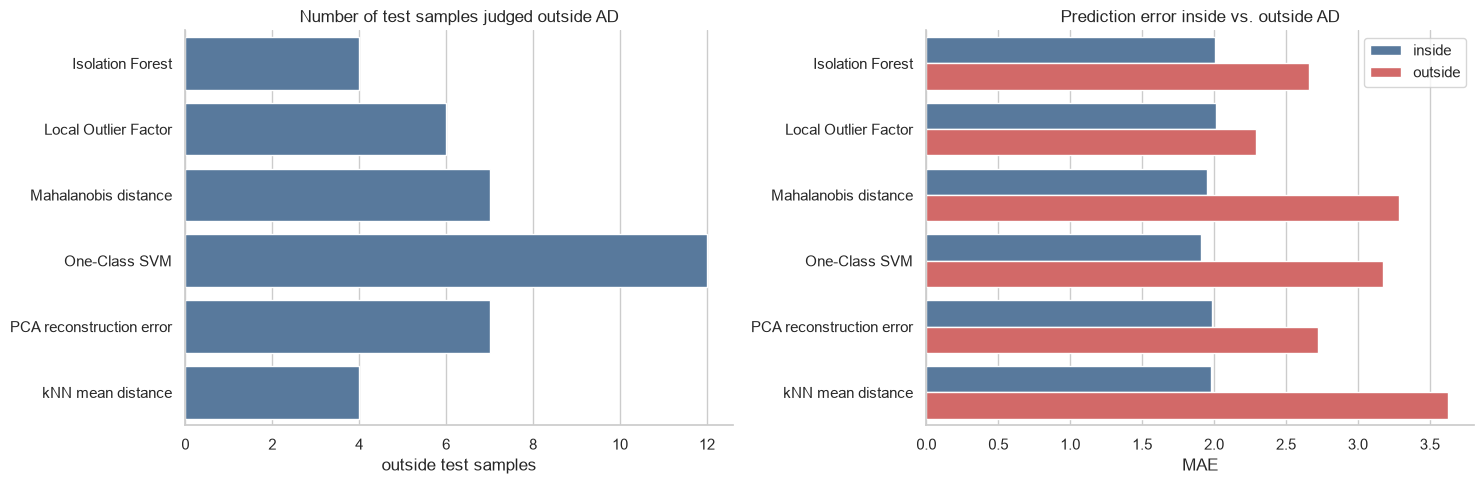

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=comparison_summary,
    x="outside_n",
    y="method",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Number of test samples judged outside AD")
axes[0].set_xlabel("outside test samples")
axes[0].set_ylabel("")

error_summary = comparison_summary.melt(
    id_vars="method",
    value_vars=["MAE_inside", "MAE_outside"],
    var_name="AD group",
    value_name="MAE",
)
error_summary["AD group"] = error_summary["AD group"].map(
    {"MAE_inside": "inside", "MAE_outside": "outside"}
)

sns.barplot(
    data=error_summary,
    x="MAE",
    y="method",
    hue="AD group",
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    ax=axes[1],
)
axes[1].set_title("Prediction error inside vs. outside AD")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("")
axes[1].legend(title=None)

plt.tight_layout()
plt.show()

## 6. 判定が割れたサンプルを確認する

複数の AD 手法で同じサンプルが AD 外になるなら、そのサンプルは特に「学習データから見て怪しい」と考えやすくなります。一方で、1手法だけが AD 外にするサンプルは、その手法の仮定に強く依存している可能性があります。

In [7]:
columns_to_show = [
    "actual_MEDV",
    "predicted_MEDV",
    "abs_error",
    "outside_method_count",
    "outside_methods",
]

display(
    ad_results.sort_values(
        ["outside_method_count", "abs_error"],
        ascending=[False, False],
    )[columns_to_show].head(15).round(3)
)

print("AD外判定を受けた手法数ごとのテストサンプル数")
display(ad_results["outside_method_count"].value_counts().sort_index().rename("n_samples"))

,actual_MEDV,predicted_MEDV,abs_error,outside_method_count,outside_methods
sample_366,27.5,23.467,4.033,5,"kNN mean distance, Mahalanobis distance, PCA r..."
sample_419,8.8,6.575,2.225,5,"kNN mean distance, Mahalanobis distance, One-C..."
sample_415,7.0,7.372,0.372,5,"kNN mean distance, Mahalanobis distance, One-C..."
sample_413,17.9,10.027,7.873,4,"kNN mean distance, Mahalanobis distance, One-C..."
sample_490,7.0,12.347,5.347,2,"Mahalanobis distance, PCA reconstruction error"
sample_492,13.6,16.597,2.997,2,"Mahalanobis distance, PCA reconstruction error"
sample_210,20.0,18.056,1.944,2,"One-Class SVM, Local Outlier Factor"
sample_356,20.6,20.768,0.168,2,"Mahalanobis distance, Isolation Forest"
sample_376,15.0,23.446,8.446,1,One-Class SVM
sample_205,50.0,45.283,4.717,1,One-Class SVM


AD外判定を受けた手法数ごとのテストサンプル数


outside_method_count
0    106
1     13
2      4
4      1
5      3
Name: n_samples, dtype: int64

## 7. AD 手法どうしの一致度を見る

ここでは、2つの手法が「AD 外」と判定したサンプル集合の Jaccard 係数を計算します。

\[
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
\]

1に近いほど AD 外判定が似ており、0に近いほど異なるサンプルを AD 外として見ています。

AD外サンプル集合の重なり数


,kNN mean distance,Mahalanobis distance,PCA reconstruction error,One-Class SVM,Isolation Forest,Local Outlier Factor
kNN mean distance,4,4,1,4,3,3
Mahalanobis distance,4,7,3,4,4,3
PCA reconstruction error,1,3,7,1,0,1
One-Class SVM,4,4,1,12,3,4
Isolation Forest,3,4,0,3,4,2
Local Outlier Factor,3,3,1,4,2,6


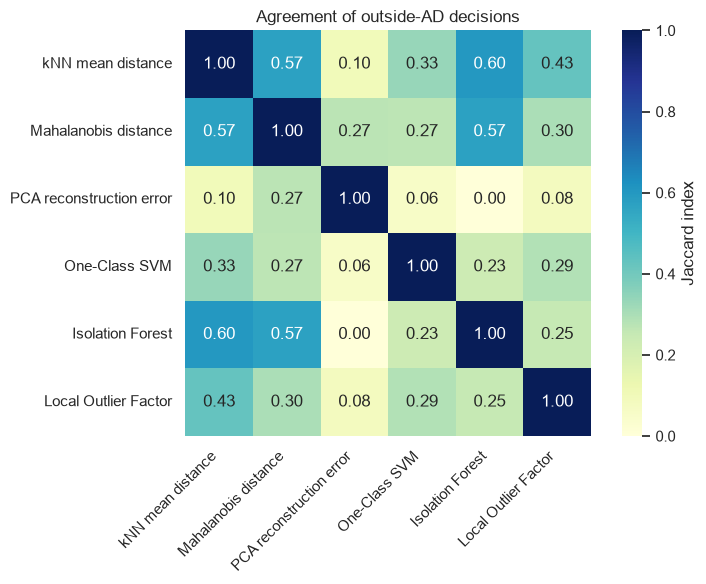

In [8]:
method_names = list(outside_matrix.columns)
jaccard_values = pd.DataFrame(index=method_names, columns=method_names, dtype=float)

def jaccard(a: pd.Series, b: pd.Series) -> float:
    union = (a | b).sum()
    if union == 0:
        return np.nan
    return float((a & b).sum() / union)

for method_a in method_names:
    for method_b in method_names:
        jaccard_values.loc[method_a, method_b] = jaccard(
            outside_matrix[method_a],
            outside_matrix[method_b],
        )

outside_overlap_count = outside_matrix.astype(int).T @ outside_matrix.astype(int)

print("AD外サンプル集合の重なり数")
display(outside_overlap_count)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    jaccard_values,
    vmin=0,
    vmax=1,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Jaccard index"},
    ax=ax,
)
ax.set_title("Agreement of outside-AD decisions")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. PCA 平面で AD 外サンプルを可視化する

AD 判定そのものは標準化後の元の特徴量空間で行っています。ここでの PCA 2次元表示は、結果を直感的に見るための補助図です。

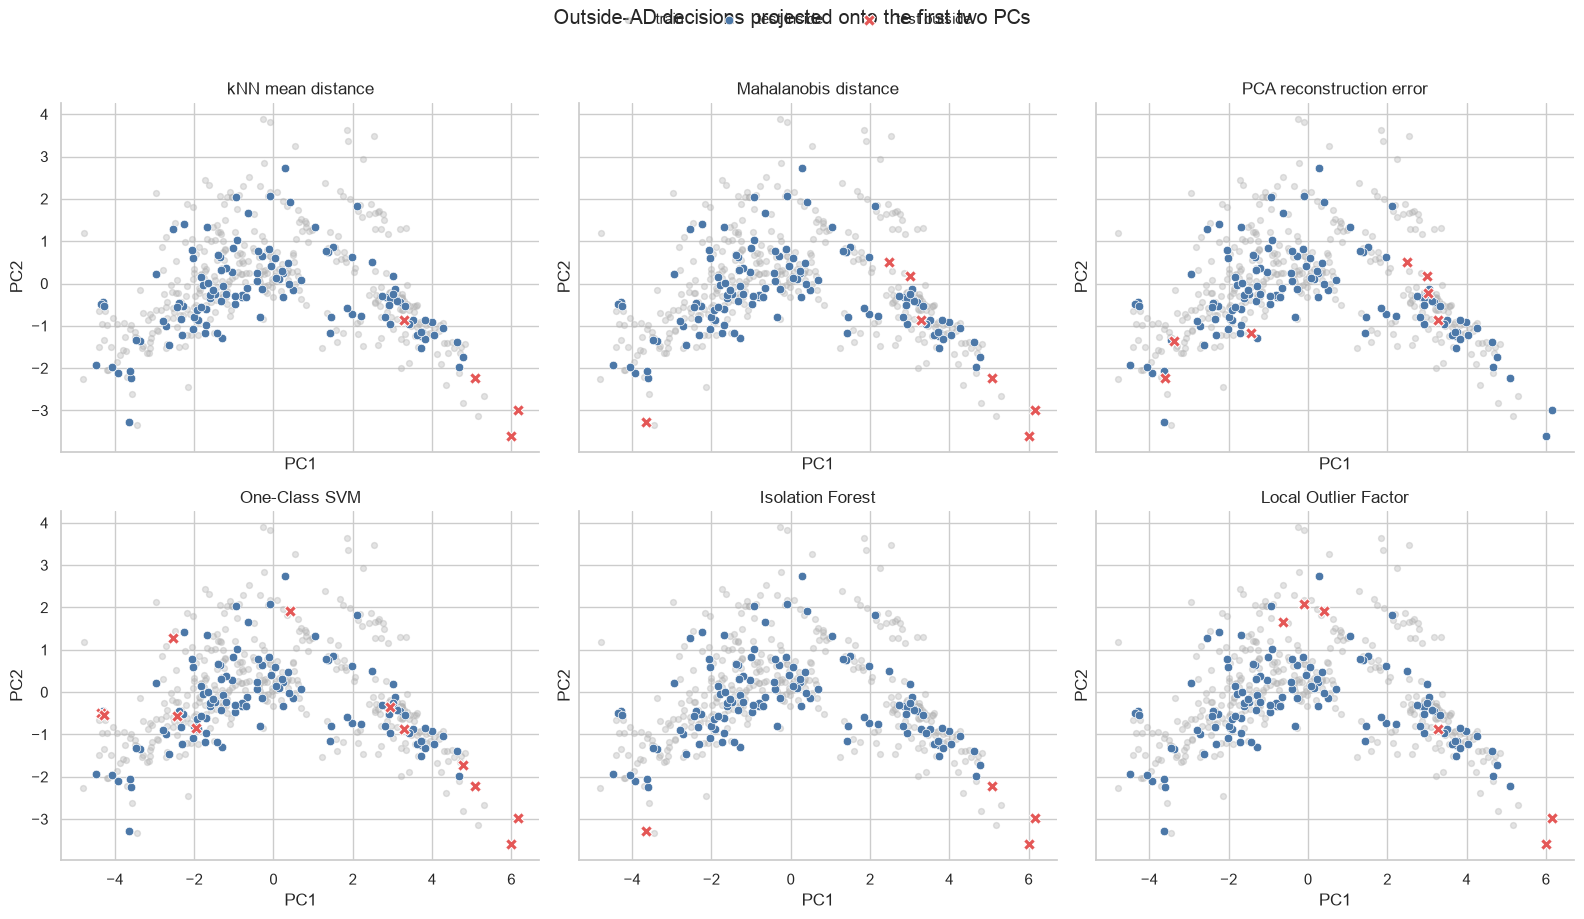

In [9]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
train_2d = pca_2d.fit_transform(X_train_scaled)
test_2d = pca_2d.transform(X_test_scaled)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, method in zip(axes, ad_methods):
    method_name = method["method"]
    is_outside = outside_matrix[method_name].to_numpy()

    ax.scatter(
        train_2d[:, 0],
        train_2d[:, 1],
        s=18,
        color="#B0B0B0",
        alpha=0.35,
        label="train",
    )
    ax.scatter(
        test_2d[~is_outside, 0],
        test_2d[~is_outside, 1],
        s=38,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.5,
        label="test inside",
    )
    ax.scatter(
        test_2d[is_outside, 0],
        test_2d[is_outside, 1],
        s=72,
        color="#E45756",
        marker="X",
        edgecolor="white",
        linewidth=0.7,
        label="test outside",
    )
    ax.set_title(method_name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Outside-AD decisions projected onto the first two PCs", y=1.02)
plt.tight_layout()
plt.show()

## 9. 代表的な手法のスコアと誤差の関係

横軸は各 AD 手法の異常度スコア、縦軸は予測の絶対誤差です。赤い破線より右側が、その手法で AD 外と判定される領域です。

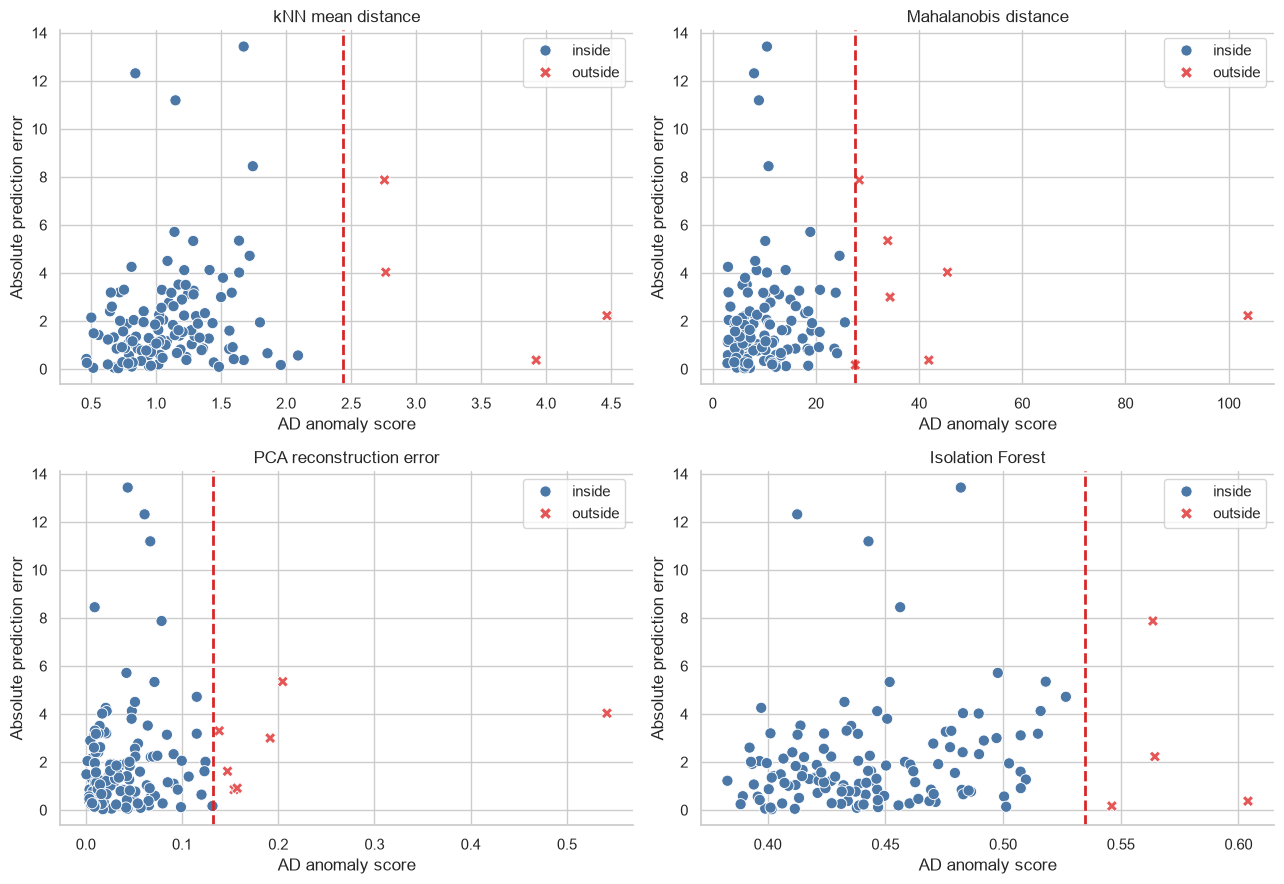

In [10]:
methods_to_plot = [
    "kNN mean distance",
    "Mahalanobis distance",
    "PCA reconstruction error",
    "Isolation Forest",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, method_name in zip(axes, methods_to_plot):
    method = next(item for item in ad_methods if item["method"] == method_name)
    short_name = method["short_name"]
    ad_label = ad_results[f"{short_name}_AD"]

    plot_df = pd.DataFrame(
        {
            "score": ad_results[f"{short_name}_score"],
            "abs_error": ad_results["abs_error"],
            "AD": ad_label,
        },
        index=ad_results.index,
    )

    sns.scatterplot(
        data=plot_df,
        x="score",
        y="abs_error",
        hue="AD",
        style="AD",
        palette={"inside": "#4C78A8", "outside": "#E45756"},
        s=65,
        ax=ax,
    )
    ax.axvline(method["threshold"], color="#D62728", linestyle="--", linewidth=2)
    ax.set_title(method_name)
    ax.set_xlabel("AD anomaly score")
    ax.set_ylabel("Absolute prediction error")
    ax.legend(title=None)

plt.tight_layout()
plt.show()

## 10. 読み取り方と注意点

- AD 外判定は「予測が必ず外れる」という判定ではなく、「学習データの分布から見ると外挿寄りなので、予測値を慎重に扱う」という警告です。
- kNN と LOF は局所的な疎密に敏感です。近傍数を変えると結果が変わります。
- Mahalanobis 距離は全体の共分散構造を見るため、単峰・楕円形に近い分布では解釈しやすい一方、非線形な分布には弱いです。
- PCA 再構成誤差は、主成分で表せない方向への外れ方に敏感です。中心から遠くても主成分方向に沿っている点は外れにくいことがあります。
- One-Class SVM、Isolation Forest、LOF は外れ値検出器として便利ですが、ハイパーパラメータや乱数に依存します。
- どの手法でも、しきい値の 95 パーセンタイルは絶対的な正解ではありません。実務では予測誤差、化学的妥当性、用途上許せるリスクと合わせて決めます。

## Exercises

1. `AD_PERCENTILE = 90` に変更し、「4. 比較する AD 判定手法」以降を再実行してください。AD 外件数と AD 外 MAE はどう変わりますか。
2. `AD_PERCENTILE = 99` に変更した場合も比較してください。AD 外が少なすぎると、平均誤差の解釈は安定するでしょうか。
3. `K_NEIGHBORS = 3` または `K_NEIGHBORS = 10` に変更し、kNN mean distance と LOF の結果がどう変わるか確認してください。

In [11]:
# 演習用の確認セル
# 上の設定値を変えてから、このセルまで再実行すると比較しやすくなります。
exercise_columns = [
    "method",
    "inside_n",
    "outside_n",
    "outside_rate",
    "MAE_inside",
    "MAE_outside",
    "RMSE_inside",
    "RMSE_outside",
]

display(
    comparison_summary[exercise_columns].round(
        {
            "outside_rate": 3,
            "MAE_inside": 3,
            "MAE_outside": 3,
            "RMSE_inside": 3,
            "RMSE_outside": 3,
        }
    )
)

,method,inside_n,outside_n,outside_rate,MAE_inside,MAE_outside,RMSE_inside,RMSE_outside
0,Isolation Forest,123,4,0.031,2.007,2.660,2.950,4.096
1,Local Outlier Factor,121,6,0.047,2.015,2.291,3.012,2.564
2,Mahalanobis distance,120,7,0.055,1.954,3.288,2.910,4.157
3,One-Class SVM,115,12,0.094,1.908,3.174,2.857,4.069
4,PCA reconstruction error,120,7,0.055,1.987,2.722,2.984,3.137
5,kNN mean distance,123,4,0.031,1.976,3.626,2.927,4.565


## まとめ

- kNN 距離以外にも、距離、密度、投影、境界、木ベースの外れ値検出を使って AD を定義できる。
- 同じ 95 パーセンタイル基準でも、手法ごとに AD 外サンプル数と選ばれるサンプルは異なる。
- AD 外サンプルの誤差が大きい傾向があれば、AD 判定は予測信頼性の補助指標として使える。
- ただし、AD 手法としきい値は仮定を含むため、1つの手法だけを正解として扱わず、複数手法の一致/不一致を確認するとよい。